#EDA

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes_dataset.csv")

In [9]:
print(df.head())
print(df.info())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [10]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [4]:
# Check null values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [15]:
print((df == 0).sum())

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [17]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [18]:
print((df == 0).sum())

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [20]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[20, 30, 40, 50, 100],
    labels=[0, 1, 2, 3]
)

df["Age_Group"] = df["Age_Group"].astype(int)

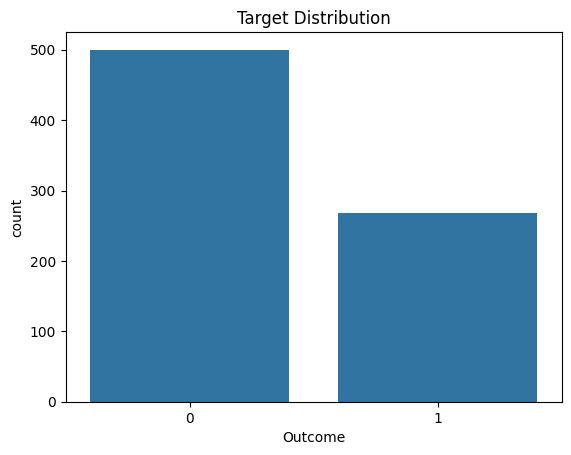

In [21]:
# Target distribution
sns.countplot(x='Outcome', data=df)
plt.title("Target Distribution")
plt.show()

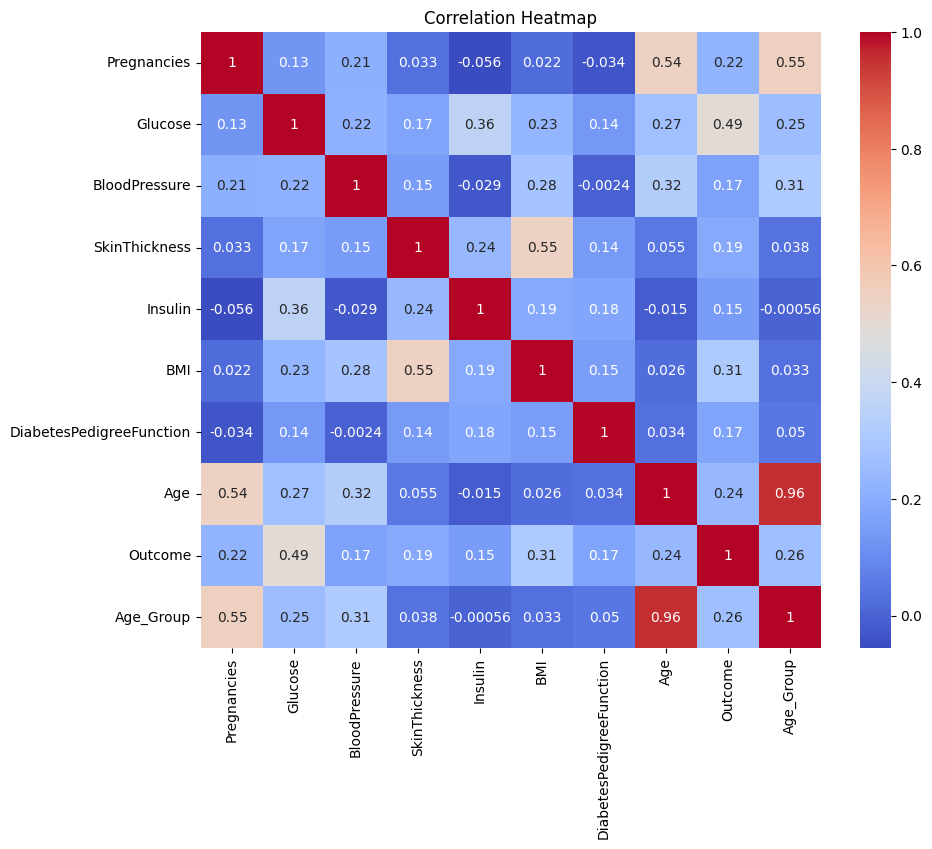

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


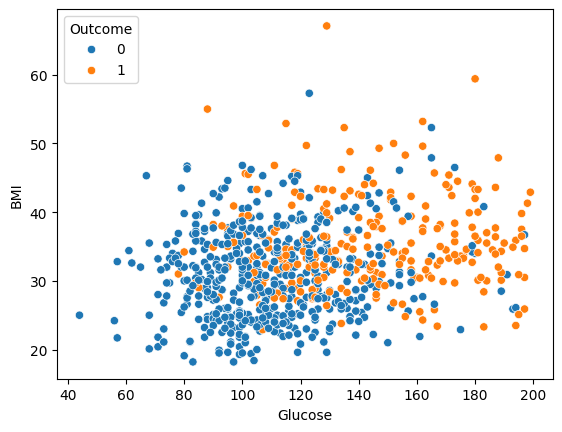

In [23]:
# Scatter example
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.show()

# Preprocessing

In [25]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Comparison

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

knn = KNeighborsClassifier(n_neighbors=5)
lr = LogisticRegression(max_iter=10000)
nb = GaussianNB()

knn.fit(X_train, y_train)
lr.fit(X_train, y_train)
nb.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_pred_lr  = lr.predict(X_test)
y_pred_nb  = nb.predict(X_test)

In [29]:
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_lr  = confusion_matrix(y_test, y_pred_lr)
cm_nb  = confusion_matrix(y_test, y_pred_nb)

print("KNN CM:\n",cm_knn)
print()
print("LR CM:\n",cm_lr)
print()
print("NB CM:\n",cm_nb)

KNN CM:
 [[79 20]
 [21 34]]

LR CM:
 [[85 14]
 [20 35]]

NB CM:
 [[75 24]
 [20 35]]


In [30]:
import numpy as np


def accuracy(cm):
    return (cm[0][0] + cm[1][1]) / np.sum(cm)

print("KNN Accuracy:", accuracy(cm_knn))
print("LR Accuracy:", accuracy(cm_lr))
print("NB Accuracy:", accuracy(cm_nb))

KNN Accuracy: 0.7337662337662337
LR Accuracy: 0.7792207792207793
NB Accuracy: 0.7142857142857143


In [32]:
def metrics(cm):
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    precision = float(TP/(TP+FP))
    recall  = float(TP/(TP+FN))
    FPR = float(FP/(FP+TN))

    return precision, recall, FPR


print("KNN :\n\n",metrics(cm_knn))
print()
print("LR :\n\n",metrics(cm_lr))
print()
print("NB :\n\n",metrics(cm_nb))

KNN :

 (0.6296296296296297, 0.6181818181818182, 0.20202020202020202)

LR :

 (0.7142857142857143, 0.6363636363636364, 0.1414141414141414)

NB :

 (0.5932203389830508, 0.6363636363636364, 0.24242424242424243)


In [33]:
def fbeta(cm,beta):
    TP = cm[1][1]
    FP = cm[0][1]
    FN = cm[1][0]

    precision = float(TP/(TP+FP))
    recall    = float(TP/(TP+FN))

    return (1+beta**2)*(precision*recall)/((beta**2*precision)+recall)

for b in [0.5,1,2]:
    print("KNN Fbeta ",b,":",fbeta(cm_knn,b))
    print()
    print("LR  Fbeta ",b,":",fbeta(cm_lr,b))
    print()
    print("NB  Fbeta ",b,":",fbeta(cm_nb,b))
    print()


KNN Fbeta  0.5 : 0.6273062730627307

LR  Fbeta  0.5 : 0.697211155378486

NB  Fbeta  0.5 : 0.6013745704467355

KNN Fbeta  1 : 0.6238532110091743

LR  Fbeta  1 : 0.673076923076923

NB  Fbeta  1 : 0.6140350877192983

KNN Fbeta  2 : 0.6204379562043796

LR  Fbeta  2 : 0.6505576208178439

NB  Fbeta  2 : 0.6272401433691757



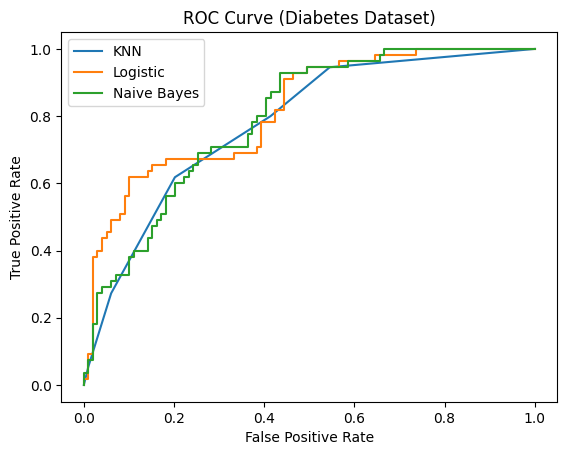

In [34]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

knn_prob = knn.predict_proba(X_test)[:,1]
lr_prob  = lr.predict_proba(X_test)[:,1]
nb_prob  = nb.predict_proba(X_test)[:,1]

fpr_knn,tpr_knn,_ = roc_curve(y_test,knn_prob)
fpr_lr,tpr_lr,_   = roc_curve(y_test,lr_prob)
fpr_nb,tpr_nb,_   = roc_curve(y_test,nb_prob)

plt.plot(fpr_knn,tpr_knn,label="KNN")
plt.plot(fpr_lr,tpr_lr,label="Logistic")
plt.plot(fpr_nb,tpr_nb,label="Naive Bayes")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Diabetes Dataset)")
plt.legend()
plt.show()


In [35]:
from sklearn.metrics import auc

auc_knn = auc(fpr_knn,tpr_knn)
auc_lr  = auc(fpr_lr,tpr_lr)
auc_nb  = auc(fpr_nb,tpr_nb)

print("KNN AUC :",auc_knn)
print("LR  AUC :",auc_lr)
print("NB  AUC :",auc_nb)

KNN AUC : 0.7786960514233241
LR  AUC : 0.8172635445362718
NB  AUC : 0.7922865013774105


{'Logistic Regression': 0.7792207792207793, 'KNN': 0.7337662337662337, 'Naive Bayes': 0.7142857142857143}


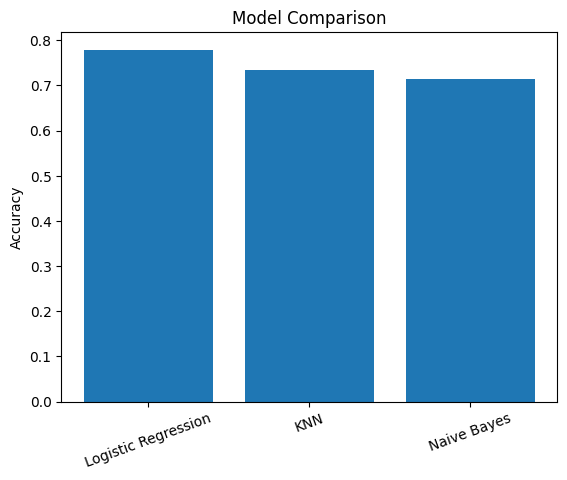

In [37]:
from sklearn.metrics import accuracy_score

results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb)
}

print(results)

plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

After comparing KNN, Logistic Regression and Naive Bayes on Diabetes Dataset , Logistic Regression performed best overall as it provided balanced Precision and Recall along with highest AUC score. Therefore Logistic Regression is the most suitable model for Diabetes Prediction in this case.